# Hafta 3 · Ders 5 — Görüntü Gradyanları ve Kenarlar

> **Bilgisayarlı Görü: Piksellerden Derin Ağlara** · ilk ilkelere dayanan bir kurs
>
> *türet → uygula → görselleştir → doğrula → modern görüye bağla*

Bir görüntü bilgisini nerede taşır? **Kenarlarında** — yoğunluğun keskin biçimde değiştiği yerlerde.
Onları bulmak için görüntünün *türevini alırız*. Bu notebook görüntü türevini sıfırdan inşa eder:
sonlu farklar, **Sobel** operatörü, gradyan büyüklüğü ve yönelimi ve sıfır-geçişli kenarlar için
**Laplas**. Bu gradyanlar Canny dedektörünün (sırada), Harris köşe dedektörünün (Hafta 4) ve —
tesadüf değil — bir CNN'in öğrenme eğilimindeki ilk filtrelerin ham malzemesidir.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import sobel as scipy_sobel
from utils.cv_utils import show, show_row, sample_gray, checkerboard, check

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. Ayrık bir görüntünün türevini alma

Sürekli bir fonksiyonun türevi onun değişim oranını ölçer. Ayrık bir görüntü için bunu bir
**sonlu farkla** yaklaşırız. En basiti *merkezi farktır*:

$$ \\frac{\\partial I}{\\partial x}[y,x] \\approx \\frac{I[y, x+1] - I[y, x-1]}{2} $$

Bu, kendisi $[+1, 0, -1]/2$ çekirdeğiyle bir evrişimdir. Yatay bir türev *dikey* kenarlara yanıt
verir (yana doğru hareket ederken karanlıktan aydınlığa geçtiğiniz yerler) ve tersi de geçerlidir.

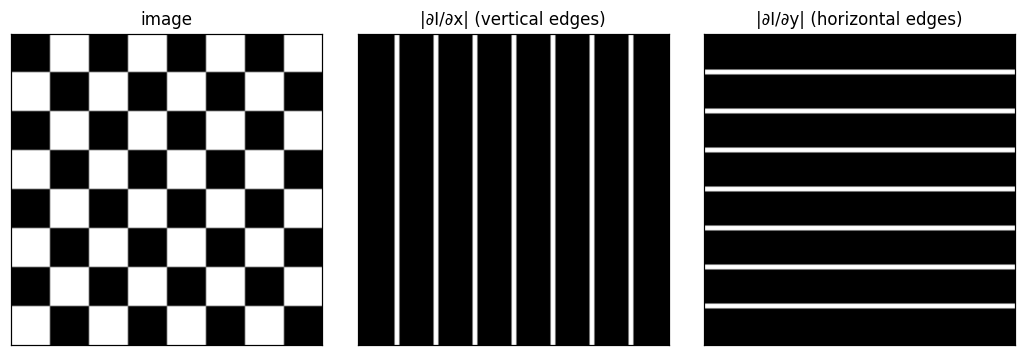

In [2]:
def convolve2d(image, kernel, pad="reflect"):
    image, kernel = np.asarray(image, float), np.asarray(kernel, float)
    kh, kw = kernel.shape; ph, pw = kh // 2, kw // 2
    kflip = kernel[::-1, ::-1]
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode=pad)
    out = np.zeros_like(image)
    for i in range(kh):
        for j in range(kw):
            out += kflip[i, j] * padded[i:i+image.shape[0], j:j+image.shape[1]]
    return out

img = checkerboard(128, squares=8)
dx = convolve2d(img, np.array([[1, 0, -1]]) / 2)     # yatay türev
dy = convolve2d(img, np.array([[1], [0], [-1]]) / 2) # dikey türev

show_row([img, np.abs(dx), np.abs(dy)],
         ["görüntü", "|∂I/∂x| (dikey kenarlar)", "|∂I/∂y| (yatay kenarlar)"])
plt.show()

## 2. Sobel operatörü: önce pürüzsüzleştir sonra türev al

Düz farklar gürültüyü büyütür. **Sobel** çekirdekleri, bir yöndeki türevi diğer yöndeki hafif
pürüzsüzleştirmeyle birleştirir — ayrılabilir, Gauss-türevi-benzeri bir filtre:

$$ S_x = \\begin{bmatrix} -1 & 0 & 1 \\\\ -2 & 0 & 2 \\\\ -1 & 0 & 1 \\end{bmatrix}, \\qquad S_y = S_x^\\top $$

$[1, 2, 1]$ sütunu küçük bir pürüzsüzleştiricidir; $[-1, 0, 1]$ satırı ise türevdir. Bu, klasik
görünün beygir gücü gradyan operatörüdür.

[PASS] Sobel-x matches scipy (up to sign) max|Δ| = 2.22e-16


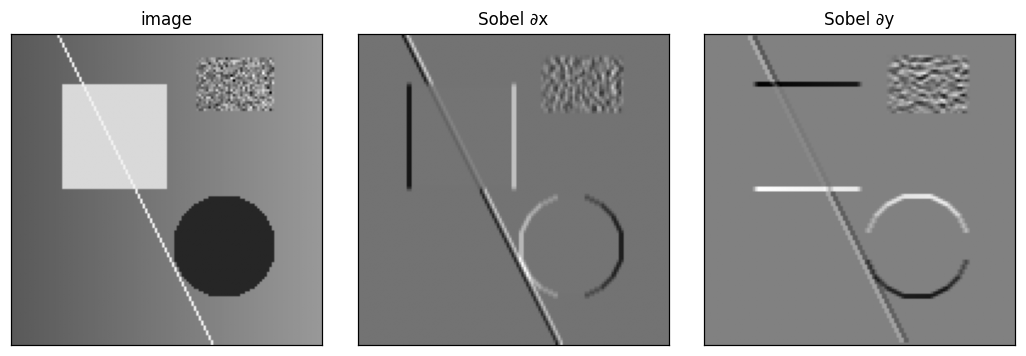

In [3]:
SOBEL_X = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], float)
SOBEL_Y = SOBEL_X.T

def sobel_gradients(image):
    gx = convolve2d(image, SOBEL_X)
    gy = convolve2d(image, SOBEL_Y)
    return gx, gy

photo = sample_gray(128)
gx, gy = sobel_gradients(photo)

# scipy'nin sobel'i aynı çekirdeği kullanır (işaret/ölçek farkıyla) — x-gradyan yapısını karşılaştır
ref = scipy_sobel(photo, axis=1, mode="mirror")
# scipy'nin Sobel'i zıt işaret geleneği kullanır, bu yüzden mutlak değeri (kenar yapısı) karşılaştır
check("Sobel-x scipy ile eşleşir (işaret farkıyla)", np.abs(gx) / np.abs(gx).max(),
      np.abs(ref) / np.abs(ref).max(), atol=1e-6)
show_row([photo, gx, gy], ["görüntü", "Sobel ∂x", "Sobel ∂y"])
plt.show()

## 3. Gradyan büyüklüğü ve yönelimi

Gradyan, her pikselde bir *vektördür* $(g_x, g_y)$. **Büyüklüğü** kenarın ne kadar güçlü olduğunu
söyler; **yönelimi** kenarın hangi yönde uzandığını söyler:

$$ |\\nabla I| = \\sqrt{g_x^2 + g_y^2}, \\qquad \\theta = \\operatorname{atan2}(g_y, g_x) $$

Büyüklük klasik "kenar görüntüsüdür". Yönelim, Canny dedektörünün ve HOG betimleyicilerinin dayandığı
şeydir. Her ikisini de görselleştirelim.

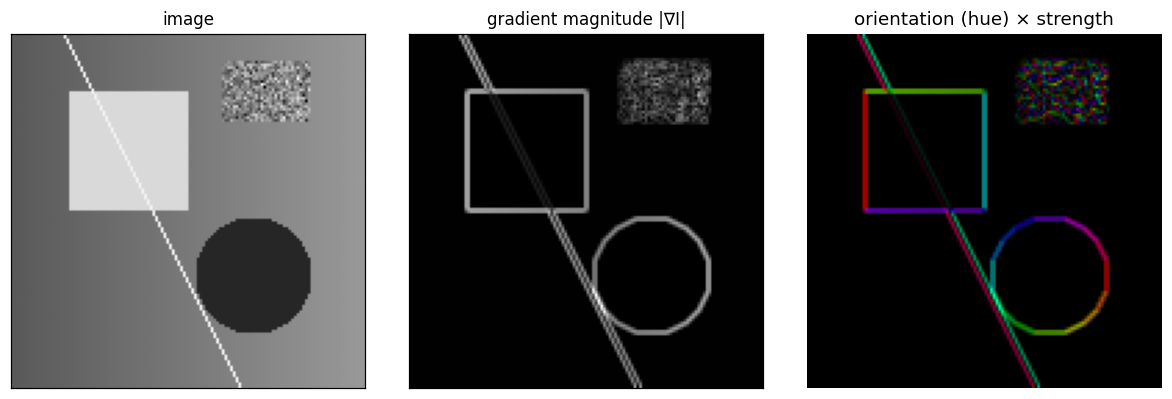

In [4]:
def gradient_magnitude_orientation(image):
    gx, gy = sobel_gradients(image)
    mag = np.sqrt(gx**2 + gy**2)
    ori = np.arctan2(gy, gx)
    return mag, ori

mag, ori = gradient_magnitude_orientation(photo)
mag_n = mag / (mag.max() + 1e-9)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
show(photo, "görüntü", ax=axes[0])
show(mag_n, "gradyan büyüklüğü |∇I|", ax=axes[1])
# yönelim yalnızca kenarların güçlü olduğu yerde, HSV ton (hue) üzerinden gösterilir
hsv = np.zeros((*ori.shape, 3))
hsv[..., 0] = (ori + np.pi) / (2 * np.pi)          # ton = yön
hsv[..., 1] = 1.0
hsv[..., 2] = mag_n                                 # parlaklık = kenar gücü
import matplotlib.colors as mcolors
axes[2].imshow(mcolors.hsv_to_rgb(hsv)); axes[2].axis("off"); axes[2].set_title("yönelim (ton) × güç")
plt.tight_layout(); plt.show()

## 4. Laplas: ikinci türevler ve sıfır-geçişleri

**Laplas**, ikinci türevleri toplar, $\\nabla^2 I = \\partial^2_x I + \\partial^2_y I$. Kenarlar,
tepeler olarak değil, Laplas'ın **sıfır-geçişleri** olarak görünür — işaret değiştirdiği noktalar.
Tek başına kullanıldığında gürültüye duyarlıdır, bu yüzden bir Gauss ile eşleştirilerek
**Gauss'un Laplas'ı (LoG)** oluşturulur; bu da Ders 4'teki Gauss Farkı tarafından yakından yaklaşılır.

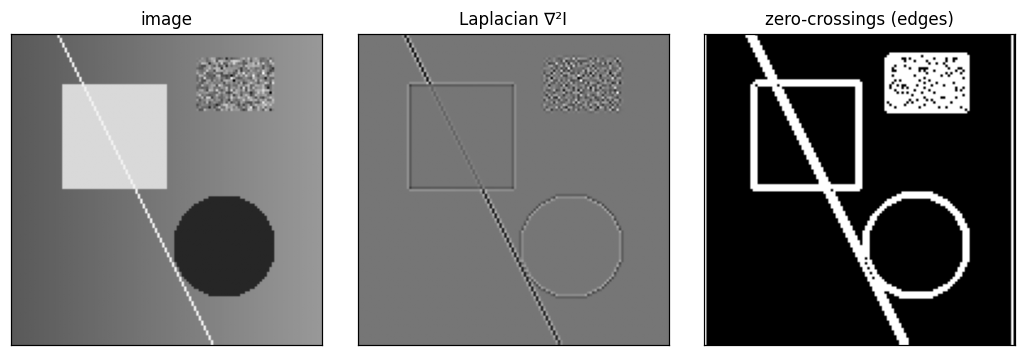

In [5]:
LAPLACIAN = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], float)

def laplacian(image):
    return convolve2d(image, LAPLACIAN)

lap = laplacian(photo)
# sıfır-geçiş haritası: komşu Laplas değerlerinin işaret değiştirdiği yerler
zc = np.zeros_like(lap)
zc[:-1, :] += (np.sign(lap[:-1, :]) != np.sign(lap[1:, :]))
zc[:, :-1] += (np.sign(lap[:, :-1]) != np.sign(lap[:, 1:]))
show_row([photo, lap, (zc > 0).astype(float)],
         ["görüntü", "Laplas ∇²I", "sıfır-geçişleri (kenarlar)"])
plt.show()

## 5. Neden önce pürüzsüzleştirmek şart

Türev alma yüksek frekanslı gürültüyü büyütür. Gürültülü bir görüntüde ham Sobel bir karmaşa üretir;
önce bulanıklaştırmak (Ders 4) temiz kenarlar verir. Bu bulanıklaştır-sonra-türev-al dizisi —
biçimsel olarak bir *Gauss türevi* — Canny'nin gelecek derste biçimselleştirdiği şeyin ta kendisidir.

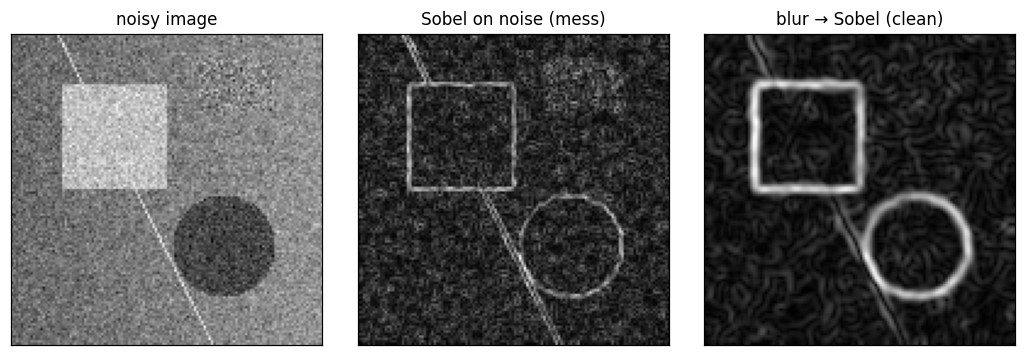

In [6]:
rng = np.random.default_rng(0)
noisy = photo + 0.12 * rng.standard_normal(photo.shape)

def gaussian_blur(image, sigma):
    r = int(np.ceil(3 * sigma)); x = np.arange(-r, r+1)
    g = np.exp(-x**2 / (2*sigma**2)); g /= g.sum()
    tmp = convolve2d(image, g.reshape(1, -1))
    return convolve2d(tmp, g.reshape(-1, 1))

raw_mag, _   = gradient_magnitude_orientation(noisy)
clean_mag, _ = gradient_magnitude_orientation(gaussian_blur(noisy, 1.5))
show_row([noisy, raw_mag / (raw_mag.max()+1e-9), clean_mag / (clean_mag.max()+1e-9)],
         ["gürültülü görüntü", "gürültü üzerinde Sobel (karmaşa)", "bulanıklaştır → Sobel (temiz)"])
plt.show()

## 6. Bunun modern görüde nerede karşımıza çıktığı

- **CNN'ler Sobel'i yeniden keşfeder.** Eğitilmiş hemen hemen herhangi bir görü ağının ilk evrişim
  katmanını görselleştirin, tam da Sobel çekirdeklerine benzeyen yönelimli kenar filtreleri
  bulursunuz — ağ, kenarların doğru düşük-seviye öznitelikler olduğunu *öğrenir*.
- **HOG ve SIFT**, bölgeleri gradyan yönelimlerinin histogramlarıyla betimler — doğrudan §3'teki
  $\\theta$ haritası.
- Bölütleme ve derinlik kestiriminde **kenar-farkında kayıplar (edge-aware losses)**, gradyanların
  yakınındaki hataları tam da bu mekanizmayı kullanarak cezalandırır.

Önizleme: gradyan yönelimlerinin bir histogramı (HOG betimleyicisinin kalbi).

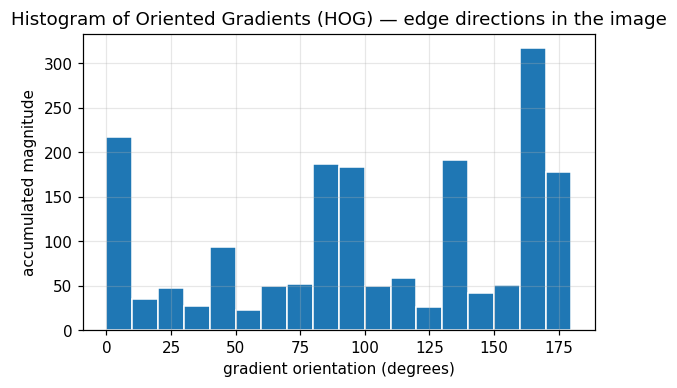

In [7]:
mag, ori = gradient_magnitude_orientation(photo)
strong = mag > 0.1 * mag.max()
angles = (ori[strong] % np.pi)                        # işaretsiz yönelim, [0, π)
plt.figure(figsize=(6, 3.5))
plt.hist(np.degrees(angles), bins=18, weights=mag[strong], color="C0", edgecolor="white")
plt.xlabel("gradyan yönelimi (derece)"); plt.ylabel("birikmiş büyüklük")
plt.title("Yönelimli Gradyan Histogramı (HOG) — görüntüdeki kenar yönleri")
plt.grid(alpha=0.3); plt.show()

## Alıştırmalar

1. **Prewitt vs Sobel.** Prewitt operatörü $[1,2,1]$ yerine $[1,1,1]$ pürüzsüzleştirmesi kullanır. Uygula ve kenar kalitesini karşılaştır.
2. **Yönelimli kenarlar.** 45° çapraz kenarlara maksimum yanıt veren bir çekirdek inşa et. Satranç tahtasında doğrula.
3. **Bir rampanın gradyanı.** Pürüzsüz doğrusal bir rampaya Sobel uygula. Gradyan ne olmalı ve sonucun uyuyor mu?

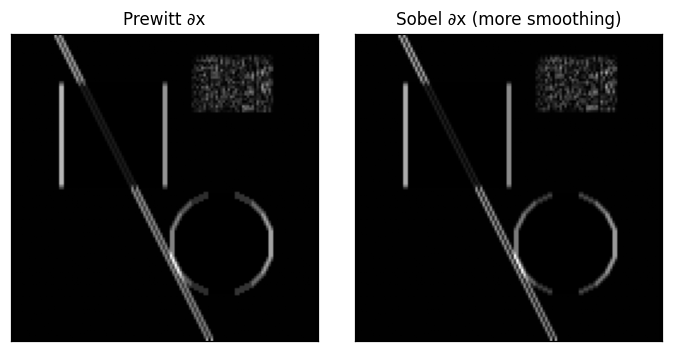

interior ∂x of a 0→1 ramp is ~constant: -0.063  (Sobel-x scale × slope)


In [8]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1. Prewitt
PREWITT_X = np.array([[-1,0,1],[-1,0,1],[-1,0,1]], float)
pw = convolve2d(photo, PREWITT_X)
sb = convolve2d(photo, SOBEL_X)
show_row([np.abs(pw), np.abs(sb)], ["Prewitt ∂x", "Sobel ∂x (daha fazla pürüzsüzleştirme)"])
plt.show()

# 3. doğrusal bir rampanın gradyanı sabittir
ramp = np.tile(np.linspace(0, 1, 128), (128, 1))
gx, _ = sobel_gradients(ramp)
print("0→1 rampasının iç bölge ∂x'i ~sabittir:", round(gx[64, 64], 4),
      " (Sobel-x ölçeği × eğim)")

## Özet ve sırada ne var

Bir görüntünün sonlu farklarla (Sobel) türevini almak kenarları bulur; gradyanın büyüklüğü kenar
gücünü ölçer ve yönelimi kenar yönünü ölçer; Laplas kenarları sıfır-geçişleri olarak konumlandırır;
ve gürültüye karşı önce pürüzsüzleştirmek şarttır.

**Sırada — `06_canny_edge_detector.ipynb`:** bu parçaları ünlü **Canny kenar dedektörü** içinde bir
araya getiriyoruz — bulanıklaştırma, gradyan, maksimum olmayanın bastırılması ve histerezis eşikleme —
klasik kenar tespitinin altın standardı, baştan sona inşa edilmiş.

---
*Bilgisayarlı Görü · Hafta 3 · Ders 5*